In [84]:
import pandas as pd
import numpy as np

In [85]:
df = pd.read_csv("C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_5_daily.csv")
df.head()

,Equipment_ID,Date,daily_heating_hours,daily_cooling_hours,daily_off_hours,daily_unknown_hours,daily_runtime_hours,daily_fan_on_hours,fan_runtime_ratio,setpoint_change_count,...,outdoor_hum_skewness,outdoor_hum_kurtosis_excess,outdoor_hum_raw_moment_2,outdoor_hum_raw_moment_3,true_outside_min,true_outside_max,true_outside_mean,true_humidity_mean,outdoor_temp_trend_gradient,temp_gradient_mean
0,timeseries_table_timeseries_table (5),2025-03-21,1.589722,0.0,7.494722,0.000000,1.589722,0.0,0.0,0,...,-0.089850,-1.061386,1669.081807,71209.918555,-0.82,15.86,7.772283,55.489130,-1.119470,NaN
1,timeseries_table_timeseries_table (5),2025-03-22,2.330556,0.0,21.601389,0.068056,2.330556,0.0,0.0,0,...,0.350349,-0.543261,2145.977883,104727.000457,6.65,19.28,12.714362,45.489362,-0.836108,NaN
2,timeseries_table_timeseries_table (5),2025-03-23,0.924722,0.0,22.918889,0.156389,0.924722,0.0,0.0,0,...,0.418737,-1.542229,4608.332566,332767.603316,8.72,21.69,15.338404,66.180851,0.110367,NaN
3,timeseries_table_timeseries_table (5),2025-03-24,0.865833,0.0,23.134167,0.000000,0.865833,0.0,0.0,0,...,0.172685,-1.680705,3979.910880,287869.620116,8.00,19.37,13.693474,59.610526,0.290054,NaN
4,timeseries_table_timeseries_table (5),2025-03-25,0.797222,0.0,23.202778,0.000000,0.797222,0.0,0.0,0,...,-0.188854,-1.435763,2952.400936,167544.114420,9.15,22.24,14.854516,52.774194,-0.341474,NaN


In [86]:
#see preprocessing/eda script. too many features is creating unneccessary noise for the linear model
#we will drop dense amounts of temperature features and setpoint features to help decrease the noise
lag_worthy_features = [
#    "daily_off_hours", 
    "daily_heating_hours",
    "daily_cooling_hours",
#    "temp_gradient_mean",
#    "setpoint_gap_mean",
#    "outdoor_temp_min",
#    "outdoor_temp_raw_moment_3",
#    "outdoor_temp_mean",
#    "outdoor_temp_time_weighted_mean",
#    "outdoor_temp_max",
#    "outdoor_temp_q25",
#    "outdoor_temp_median",
#    "outdoor_temp_q75",
#    "outdoor_temp_raw_moment_2",
#    "setpoint_raw_moment_2",
#   "setpoint_mean",
#    "setpoint_raw_moment_3",
    "setpoint_time_weighted_mean",
#    "daily_unknown_hours",
    "daily_runtime_hours",
    "true_outside_mean",
#    "true_outside_min",
#    "true_outside_max",
    "true_humidity_mean",
]
same_day_features = [
    "month",
    "outdoor_temp_trend_gradient",
    "Date"
]

#best solution here - light gbm learns what na means - Linear Regression doesnt.
df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
    ["temp_gradient_mean", "setpoint_gap_mean"]
].fillna(0)

df = df[lag_worthy_features + same_day_features]
df = df.dropna()

#filter so that we have the largest group of continuous days not missing values
df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
gaps = df[df['day_gap'] != 1]
groups = (df['day_gap'] > 1).cumsum()
largest_group = groups.value_counts().idxmax()
df = df[groups == largest_group]

In [87]:
lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]

LAG_DAYS = 1

lags = []
for i in range(1, LAG_DAYS + 1):

    s = df[lag_cols_for_shift].shift(i)

    s.columns = [f"{c}_lag_{i}" for c in s.columns]

    lags.append(s)

df_lags = pd.concat([df] + lags, axis=1)


same_day_feats = [f for f in df_lags.columns if f in same_day_features]

lag_feats = [c for c in df_lags.columns if "_lag_" in c]

day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]

final_feature_set = day_only_feats + lag_feats

print(f"\nfinal feature set: {len(final_feature_set)} total")
print(f"  same-day exogenous features: {len(day_only_feats)}")
print(f"  lag features: {len(lag_feats)}")


final feature set: 9 total
  same-day exogenous features: 3
  lag features: 6


In [88]:
window_size = 28

df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
df_lags_dropped = df_lags.dropna() #drop lagged which are missing

dates = df_lags_dropped["Date"]
X = df_lags_dropped[final_feature_set].drop(columns="Date")
y = df_lags_dropped["daily_runtime_hours"]

windows = []



for end in range(window_size, len(y) - 1 + 1):
    start = end - window_size

    X_train = X[start:end]
    y_train = y[start:end]
    
    X_test = X[end:end + 1]
    y_test = y[end:end + 1]

    test_date = dates.iloc[end]
    
    windows.append((X_train, y_train, X_test, y_test, test_date))

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

predictions = []
coefs = []


for X_train, y_train, X_test, y_test, test_date in windows:
    
    scaler = StandardScaler()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = Lasso(alpha = 0.45)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)[0]
    if y_pred > 24:
        y_pred = 24
    elif y_pred < 0:
        y_pred = 0
    
    predictions.append({
        'y_true': y_test.iloc[0],
        'y_pred': y_pred,
        'date': test_date
    })

    coefs.append(model.coef_)

avg_coef = np.mean(coefs, axis=0)
pred_df = pd.DataFrame(predictions)
print(pred_df)

       y_true    y_pred        date
0    0.665278  1.027669  2025-04-19
1    0.665278  0.968194  2025-04-20
2    0.553611  0.958929  2025-04-21
3    0.613889  0.947778  2025-04-22
4    0.667500  0.941230  2025-04-23
..        ...       ...         ...
208  5.956389  1.295346  2025-11-13
209  4.323611  3.178253  2025-11-14
210  0.337500  2.619205  2025-11-15
211  0.504722  0.246047  2025-11-16
212  2.461667  0.955297  2025-11-17

[213 rows x 3 columns]


In [90]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
print("MSE:",mse) 

print("RMSE:", np.sqrt(mse))

MSE: 7.172041391211726
RMSE: 2.678066726430043


Text(0, 0.5, 'Hours')

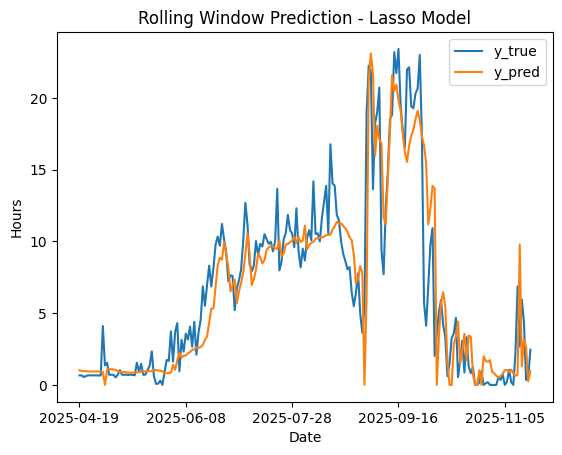

In [94]:
chart = pred_df.set_index('date')[['y_true', 'y_pred']].plot(
    title='Rolling Window Prediction - Lasso Model'
)

chart.set_xlabel("Date")
chart.set_ylabel("Hours")

In [92]:
y_true = pred_df["y_true"].to_numpy()
y_pred = pred_df["y_pred"].to_numpy()

In [93]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
)

mae = mean_absolute_error(y_true, y_pred)
medae = np.median(np.abs(y_true - y_pred))
maxae = np.max(np.abs(y_true - y_pred))

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100.0 * np.mean(np.abs((y_true - y_pred) / (y_true + eps)))

mape_val = mape(y_true, y_pred)
smape_val = smape(y_true, y_pred)

r2 = r2_score(y_true, y_pred)
evs = explained_variance_score(y_true, y_pred)

metrics = pd.Series({
    "MSE": mse,
    "RMSE": np.sqrt(mse),
    "MAE": mae,
    "MedianAE": medae,
    "MaxAE": maxae,
    "MAPE (%)": mape_val,
    "sMAPE (%)": smape_val,
    "R2": r2,
    "ExplainedVariance": evs,
})

print("\n=== Model Evaluation (Rolling Predictions) ===")
display(metrics.to_frame("value"))


=== Model Evaluation (Rolling Predictions) ===


,value
MSE,7.172041e+00
RMSE,2.678067e+00
MAE,1.719669e+00
MedianAE,9.581444e-01
MaxAE,1.295741e+01
MAPE (%),4.154275e+08
sMAPE (%),4.949421e+01
R2,8.152579e-01
ExplainedVariance,8.166345e-01


In [60]:
mse_list = []
rmse_list = []
mae_list = []
medae_list = []
maxae_list = []
mape_list = []
smape_list = []
r2_list = []
evs_list = []
data_count_list = []
dropped_rows_list = []
flagged_list = []
pooled_pairs = []

window_size = 28
LAG_DAYS = 1

for i in range (1, 101):
    file_path = "C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_" + str(i) +"_daily.csv"
    df = pd.read_csv(file_path)

    #best solution here - light gbm learns what nan means - Linear Regression doesnt.
    df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
        ["temp_gradient_mean", "setpoint_gap_mean"]
    ].fillna(0)
    
    df = df[lag_worthy_features + same_day_features]
    df = df.dropna()
    
    #filter so that we have the largest group of continuous days not missing values
    df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
    gaps = df[df['day_gap'] != 1]
    groups = (df['day_gap'] > 1).cumsum()
    try:
        largest_group = groups.value_counts().idxmax()
        df = df[groups == largest_group]
    except:
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        sample_count_list.append(0)
        flagged_list.append(i*100)
        pooled_pairs.append([],[])
        continue
        

    lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]


    
    lags = []
    for j in range(1, LAG_DAYS + 1):
    
        s = df[lag_cols_for_shift].shift(j)
    
        s.columns = [f"{c}_lag_{j}" for c in s.columns]
    
        lags.append(s)
    
    df_lags = pd.concat([df] + lags, axis=1)
    
    same_day_feats = [f for f in df_lags.columns if f in same_day_features]
    
    lag_feats = [c for c in df_lags.columns if "_lag_" in c]
    
    day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]
    
    final_feature_set = day_only_feats + lag_feats

    df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
    
    df_lags_count_initial = len(df_lags)
    df_lags_dropped = df_lags.dropna()
    df_lags_count_final = len(df_lags_dropped)
    dropped_rows_list.append(df_lags_count_initial-df_lags_count_final) 
    
    dates = df_lags_dropped["Date"]
    X = df_lags_dropped[final_feature_set].drop(columns="Date")
    y = df_lags_dropped["daily_runtime_hours"]
    
    data_count_list.append(len(X))

    if len(X) < (window_size * 2):
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        flagged_list.append(i)
        pooled_pairs.append(([], []))
        continue
    
    windows = []
    
    
    
    for end in range(window_size, len(y) - 1 + 1):
        start = end - window_size
    
        X_train = X[start:end]
        y_train = y[start:end]
        
        X_test = X[end:end + 1]
        y_test = y[end:end + 1]
    
        test_date = dates.iloc[end]
        
        windows.append((X_train, y_train, X_test, y_test, test_date))

    predictions = []
    coefs = []
    
    
    for X_train, y_train, X_test, y_test, test_date in windows:
        scaler = StandardScaler()
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = LinearRegression()
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)[0]
        if y_pred > 24:
            y_pred = 24
        elif y_pred < 0:
            y_pred = 0
        
        predictions.append({
            'y_true': y_test.iloc[0],
            'y_pred': y_pred,
            'date': test_date
        })
    
        coefs.append(model.coef_)
    
    avg_coef = np.mean(coefs, axis=0)
    pred_df = pd.DataFrame(predictions)

    if len(pred_df) == 0:
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        flagged_list.append(i)
        pooled_pairs.append(([], []))
        continue

    mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
    
    y_true = pred_df["y_true"].to_numpy()
    y_pred = pred_df["y_pred"].to_numpy()

    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    maxae = np.max(np.abs(y_true - y_pred))

    mape_val = mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))
    mae_list.append(mae)
    medae_list.append(medae)
    maxae_list.append(maxae)
    mape_list.append(mape_val)
    smape_list.append(smape_val)
    r2_list.append(r2)
    evs_list.append(evs)
    pooled_pairs.append((pred_df["y_true"].to_numpy(), pred_df["y_pred"].to_numpy()))

    

print("Files flagged for null values:", flagged_list)

Files flagged for null values: [22]


In [61]:
outlier_indices = [i for i, val in enumerate(r2_list) if val < -1]
print(outlier_indices)

[21]


In [62]:
all_metric_lists = {
    "mse": mse_list,
    "rmse": rmse_list,
    "mae": mae_list,
    "medae": medae_list,
    "maxae": maxae_list,
    "mape": mape_list,
    "smape": smape_list,
    "r2": r2_list,
    "evs": evs_list,
    "data-count": data_count_list
}

filtered_data = {
    name: [val for i, val in enumerate(lst) if i not in outlier_indices]
    for name, lst in all_metric_lists.items()
}

filtered_pairs = [
    pair for i, pair in enumerate(pooled_pairs)
    if i not in outlier_indices
]

pooled_y_true = np.concatenate([p[0] for p in filtered_pairs])
pooled_y_pred = np.concatenate([p[1] for p in filtered_pairs])

pooled_r2 = r2_score(pooled_y_true, pooled_y_pred)

mse_list = filtered_data["mse"]
rmse_list = filtered_data["rmse"]
mae_list = filtered_data["mae"]
medae_list = filtered_data["medae"]
maxae_list = filtered_data["maxae"]
mape_list = filtered_data["mape"]
smape_list = filtered_data["smape"]
r2_list = filtered_data["r2"]
evs_list = filtered_data["evs"]
data_count_list = filtered_data["data-count"]

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
    "Pooled R2": pooled_r2,
})

print(avg_metrics)

MSE                  1.044309e+01
RMSE                 3.074397e+00
MAE                  2.088333e+00
MedianAE             1.420331e+00
MaxAE                1.458926e+01
MAPE (%)             9.745910e+08
sMAPE (%)            5.568438e+01
R2                   4.763362e-01
ExplainedVariance    4.785498e-01
Pooled R2            6.334492e-01
dtype: float64


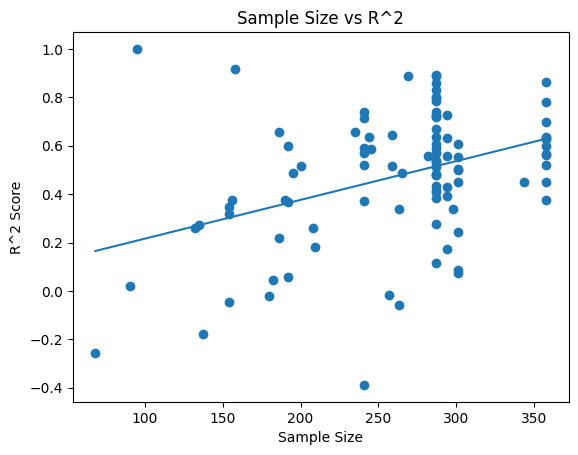

In [63]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(data_count_list, r2_list)

# fit linear trendline
z = np.polyfit(data_count_list, r2_list, 1)
p = np.poly1d(z)

# plot trendline (sorted x for clean line)
x_sorted = np.sort(data_count_list)
plt.plot(x_sorted, p(x_sorted))

plt.xlabel("Sample Size")
plt.ylabel("R^2 Score")
plt.title("Sample Size vs R^2")

plt.show()

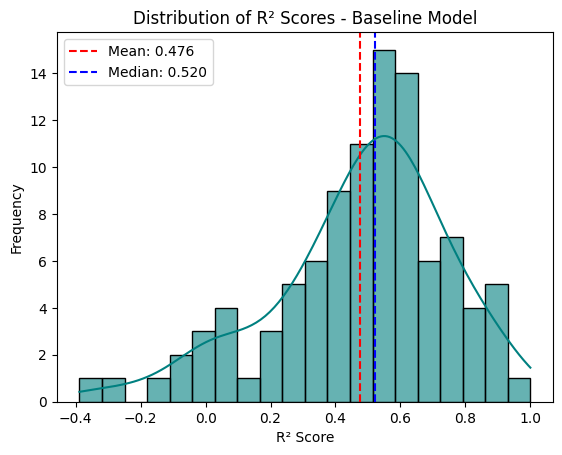

In [64]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

mean_val = np.mean(r2_list)
median_val = np.median(r2_list)

sns.histplot(r2_list, bins=20, kde=True, color='teal', alpha=0.6)

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
plt.axvline(median_val, color='blue', linestyle='--', label=f'Median: {median_val:.3f}')

plt.title("Distribution of R² Scores - Baseline Model")
plt.xlabel("R² Score")
plt.ylabel("Frequency")

plt.legend()
plt.show()

# Testing Number of Lag Days and Window Size

In [534]:
for window_size in [7, 14, 21, 28]:
    for LAG_DAYS in [1, 7]:
        if(LAG_DAYS > window_size):
            continue
        print("Testing for", str(window_size), "day window with" , str(LAG_DAYS), "lag days...") 
        
        mse_list = []
        rmse_list = []
        mae_list = []
        medae_list = []
        maxae_list = []
        mape_list = []
        smape_list = []
        r2_list = []
        evs_list = []
        data_count_list = []
        dropped_rows_list = []
        flagged_list = []
        pooled_pairs = []
        
        for i in range (1, 51):
            file_path = "C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_" + str(i) +"_daily.csv"
            df = pd.read_csv(file_path)
        
            #best solution here - light gbm learns what nan means - Linear Regression doesnt.
            df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
                ["temp_gradient_mean", "setpoint_gap_mean"]
            ].fillna(0)
            
            df = df[lag_worthy_features + same_day_features]
            df = df.dropna()
            
            #filter so that we have the largest group of continuous days not missing values
            df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
            gaps = df[df['day_gap'] != 1]
            groups = (df['day_gap'] > 1).cumsum()
            try:
                largest_group = groups.value_counts().idxmax()
                df = df[groups == largest_group]
            except:
                mse_list.append(0)
                rmse_list.append(np.sqrt(0))
                mae_list.append(0)
                medae_list.append(0)
                maxae_list.append(0)
                mape_list.append(0)
                smape_list.append(0)
                #dummy r^2 value so that the list is filtered out
                r2_list.append(-10)
                evs_list.append(0)
                flagged_list.append(i*100)
                continue
                
        
            lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]
            
            lags = []
            for j in range(1, LAG_DAYS + 1):
            
                s = df[lag_cols_for_shift].shift(j)
            
                s.columns = [f"{c}_lag_{j}" for c in s.columns]
            
                lags.append(s)
            
            df_lags = pd.concat([df] + lags, axis=1)
            
            same_day_feats = [f for f in df_lags.columns if f in same_day_features]
            
            lag_feats = [c for c in df_lags.columns if "_lag_" in c]
            
            day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]
            
            final_feature_set = day_only_feats + lag_feats
        
            df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
            
            df_lags_count_initial = len(df_lags)
            df_lags_dropped = df_lags.dropna()
            df_lags_count_final = len(df_lags_dropped)
            dropped_rows_list.append(df_lags_count_initial-df_lags_count_final) 
            
            dates = df_lags_dropped["Date"]
            X = df_lags_dropped[final_feature_set].drop(columns="Date")
            y = df_lags_dropped["daily_runtime_hours"]
            
            data_count_list.append(len(X))
        
            if len(X) < (window_size * 2):
                mse_list.append(0)
                rmse_list.append(np.sqrt(0))
                mae_list.append(0)
                medae_list.append(0)
                maxae_list.append(0)
                mape_list.append(0)
                smape_list.append(0)
                #dummy r^2 value so that the list is filtered out
                r2_list.append(-10)
                evs_list.append(0)
                flagged_list.append(i)
                continue
            
            windows = []
            
            
            
            for end in range(window_size, len(y) - 1 + 1):
                start = end - window_size
            
                X_train = X[start:end]
                y_train = y[start:end]
                
                X_test = X[end:end + 1]
                y_test = y[end:end + 1]
            
                test_date = dates.iloc[end]
                
                windows.append((X_train, y_train, X_test, y_test, test_date))
        
            predictions = []
            coefs = []
            
            
            for X_train, y_train, X_test, y_test, test_date in windows:
                scaler = StandardScaler()
                
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                
                model = LinearRegression()
                model.fit(X_train_scaled, y_train)
                
                y_pred = model.predict(X_test_scaled)[0]
                if y_pred > 24:
                    y_pred = 24
                elif y_pred < 0:
                    y_pred = 0
        
                
                predictions.append({
                    'y_true': y_test.iloc[0],
                    'y_pred': y_pred,
                    'date': test_date
                })
            
                coefs.append(model.coef_)
            
            avg_coef = np.mean(coefs, axis=0)
            pred_df = pd.DataFrame(predictions)

            pooled_pairs.append((pred_df["y_true"].to_numpy(), pred_df["y_pred"].to_numpy()))
            
            mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
            
            y_true = pred_df["y_true"].to_numpy()
            y_pred = pred_df["y_pred"].to_numpy()
        
            mae = mean_absolute_error(y_true, y_pred)
            medae = np.median(np.abs(y_true - y_pred))
            maxae = np.max(np.abs(y_true - y_pred))
        
            mape_val = mape(y_true, y_pred)
            smape_val = smape(y_true, y_pred)
        
            r2 = r2_score(y_true, y_pred)
            evs = explained_variance_score(y_true, y_pred)
        
            mse_list.append(mse)
            rmse_list.append(np.sqrt(mse))
            mae_list.append(mae)
            medae_list.append(medae)
            maxae_list.append(maxae)
            mape_list.append(mape_val)
            smape_list.append(smape_val)
            r2_list.append(r2)
            evs_list.append(evs)
        
        outlier_indices = [i for i, val in enumerate(r2_list) if val < -1]

        all_metric_lists = {
            "mse": mse_list,
            "rmse": rmse_list,
            "mae": mae_list,
            "medae": medae_list,
            "maxae": maxae_list,
            "mape": mape_list,
            "smape": smape_list,
            "r2": r2_list,
            "evs": evs_list,
            "data-count": data_count_list,
        }
        
        filtered_data = {
            name: [val for i, val in enumerate(lst) if i not in outlier_indices]
            for name, lst in all_metric_lists.items()
        }

        filtered_pairs = [
            pair for i, pair in enumerate(pooled_pairs)
            if i not in outlier_indices
        ]
        
        pooled_y_true = np.concatenate([p[0] for p in filtered_pairs])
        pooled_y_pred = np.concatenate([p[1] for p in filtered_pairs])
        
        pooled_r2 = r2_score(pooled_y_true, pooled_y_pred)
        
        mse_list = filtered_data["mse"]
        rmse_list = filtered_data["rmse"]
        mae_list = filtered_data["mae"]
        medae_list = filtered_data["medae"]
        maxae_list = filtered_data["maxae"]
        mape_list = filtered_data["mape"]
        smape_list = filtered_data["smape"]
        r2_list = filtered_data["r2"]
        evs_list = filtered_data["evs"]
        
        avg_metrics = pd.Series({
            "MSE": np.mean(mse_list),
            "RMSE": np.mean(rmse_list),
            "MAE": np.mean(mae_list),
            "MedianAE": np.mean(medae_list),
            "MaxAE": np.mean(maxae_list),
            "MAPE (%)": np.mean(mape_list),
            "sMAPE (%)": np.mean(smape_list),
            "R2": np.mean(r2_list),
            "Pooled R2": pooled_r2,
            "ExplainedVariance": np.mean(evs_list),
            "Outliers": len(outlier_indices)
        })
        
        print(avg_metrics)

Testing for 7 day window with 1 lag days...
MSE                  4.707677e+01
RMSE                 6.743966e+00
MAE                  4.458666e+00
MedianAE             2.616219e+00
MaxAE                2.314409e+01
MAPE (%)             2.023980e+09
sMAPE (%)            8.593936e+01
R2                  -4.940420e-01
Pooled R2           -2.687001e-01
ExplainedVariance   -4.709042e-01
Outliers             2.900000e+01
dtype: float64
Testing for 7 day window with 7 lag days...
MSE                  1.765624e+01
RMSE                 4.016577e+00
MAE                  2.637408e+00
MedianAE             1.676677e+00
MaxAE                1.833532e+01
MAPE (%)             1.041490e+09
sMAPE (%)            7.167598e+01
R2                   9.074359e-02
Pooled R2            3.814892e-01
ExplainedVariance    9.488931e-02
Outliers             4.000000e+00
dtype: float64
Testing for 14 day window with 1 lag days...
MSE                  1.601175e+01
RMSE                 3.809049e+00
MAE                  

# Ridge Regression Test

In [492]:
from sklearn.linear_model import Ridge
mse_list = []
rmse_list = []
mae_list = []
medae_list = []
maxae_list = []
mape_list = []
smape_list = []
r2_list = []
evs_list = []
data_count_list = []
dropped_rows_list = []
flagged_list = []
pooled_pairs = []

window_size = 7
LAG_DAYS = 1
hp = .05

for i in range (1, 101):
    file_path = "C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_" + str(i) +"_daily.csv"
    df = pd.read_csv(file_path)

    #best solution here - light gbm learns what nan means - Linear Regression doesnt.
    df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
        ["temp_gradient_mean", "setpoint_gap_mean"]
    ].fillna(0)
    
    df = df[lag_worthy_features + same_day_features]
    df = df.dropna()
    
    #filter so that we have the largest group of continuous days not missing values
    df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
    gaps = df[df['day_gap'] != 1]
    groups = (df['day_gap'] > 1).cumsum()
    try:
        largest_group = groups.value_counts().idxmax()
        df = df[groups == largest_group]
    except:
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        sample_count_list.append(0)
        flagged_list.append(i*100)
        pooled_pairs.append([],[])
        continue
        

    lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]


    
    lags = []
    for j in range(1, LAG_DAYS + 1):
    
        s = df[lag_cols_for_shift].shift(j)
    
        s.columns = [f"{c}_lag_{j}" for c in s.columns]
    
        lags.append(s)
    
    df_lags = pd.concat([df] + lags, axis=1)
    
    same_day_feats = [f for f in df_lags.columns if f in same_day_features]
    
    lag_feats = [c for c in df_lags.columns if "_lag_" in c]
    
    day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]
    
    final_feature_set = day_only_feats + lag_feats

    df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
    
    df_lags_count_initial = len(df_lags)
    df_lags_dropped = df_lags.dropna()
    df_lags_count_final = len(df_lags_dropped)
    dropped_rows_list.append(df_lags_count_initial-df_lags_count_final) 
    
    dates = df_lags_dropped["Date"]
    X = df_lags_dropped[final_feature_set].drop(columns="Date")
    y = df_lags_dropped["daily_runtime_hours"]
    
    data_count_list.append(len(X))

    if len(X) < (window_size * 2):
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        flagged_list.append(i)
        pooled_pairs.append(([], []))
        continue
    
    windows = []
    
    
    
    for end in range(window_size, len(y) - 1 + 1):
        start = end - window_size
    
        X_train = X[start:end]
        y_train = y[start:end]
        
        X_test = X[end:end + 1]
        y_test = y[end:end + 1]
    
        test_date = dates.iloc[end]
        
        windows.append((X_train, y_train, X_test, y_test, test_date))

    predictions = []
    coefs = []
    
    
    for X_train, y_train, X_test, y_test, test_date in windows:
        scaler = StandardScaler()
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = Ridge(alpha = hp)
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)[0]
        if y_pred > 24:
            y_pred = 24
        elif y_pred < 0:
            y_pred = 0
        
        predictions.append({
            'y_true': y_test.iloc[0],
            'y_pred': y_pred,
            'date': test_date
        })
    
        coefs.append(model.coef_)
    
    avg_coef = np.mean(coefs, axis=0)
    pred_df = pd.DataFrame(predictions)

    if len(pred_df) == 0:
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        flagged_list.append(i)
        pooled_pairs.append(([], []))
        continue

    mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
    
    y_true = pred_df["y_true"].to_numpy()
    y_pred = pred_df["y_pred"].to_numpy()

    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    maxae = np.max(np.abs(y_true - y_pred))

    mape_val = mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))
    mae_list.append(mae)
    medae_list.append(medae)
    maxae_list.append(maxae)
    mape_list.append(mape_val)
    smape_list.append(smape_val)
    r2_list.append(r2)
    evs_list.append(evs)
    pooled_pairs.append((pred_df["y_true"].to_numpy(), pred_df["y_pred"].to_numpy()))

    

print("Files flagged for null values:", flagged_list)

Files flagged for null values: []


In [493]:
outlier_indices = [i for i, val in enumerate(r2_list) if val < -1]
print(outlier_indices)

[]


In [494]:
all_metric_lists = {
    "mse": mse_list,
    "rmse": rmse_list,
    "mae": mae_list,
    "medae": medae_list,
    "maxae": maxae_list,
    "mape": mape_list,
    "smape": smape_list,
    "r2": r2_list,
    "evs": evs_list,
    "data-count": data_count_list
}

filtered_data = {
    name: [val for i, val in enumerate(lst) if i not in outlier_indices]
    for name, lst in all_metric_lists.items()
}

filtered_pairs = [
    pair for i, pair in enumerate(pooled_pairs)
    if i not in outlier_indices
]

pooled_y_true = np.concatenate([p[0] for p in filtered_pairs])
pooled_y_pred = np.concatenate([p[1] for p in filtered_pairs])

pooled_r2 = r2_score(pooled_y_true, pooled_y_pred)

mse_list = filtered_data["mse"]
rmse_list = filtered_data["rmse"]
mae_list = filtered_data["mae"]
medae_list = filtered_data["medae"]
maxae_list = filtered_data["maxae"]
mape_list = filtered_data["mape"]
smape_list = filtered_data["smape"]
r2_list = filtered_data["r2"]
evs_list = filtered_data["evs"]
data_count_list = filtered_data["data-count"]

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
    "Pooled R2": pooled_r2,
})

print(avg_metrics)

MSE                  1.091952e+01
RMSE                 3.152335e+00
MAE                  2.094702e+00
MedianAE             1.368235e+00
MaxAE                1.575961e+01
MAPE (%)             8.551630e+08
sMAPE (%)            5.366016e+01
R2                   4.446378e-01
ExplainedVariance    4.460418e-01
Pooled R2            6.233960e-01
dtype: float64


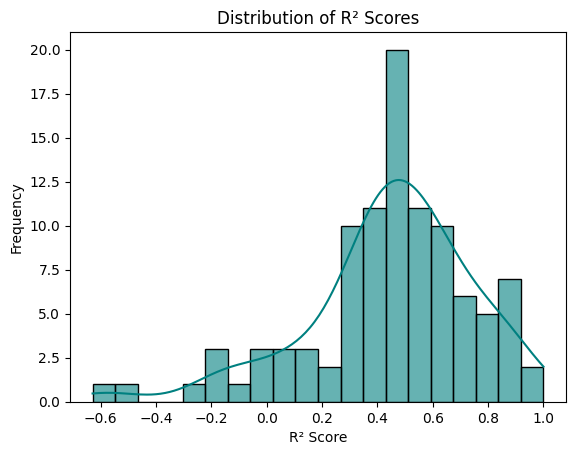

In [495]:
import seaborn as sns

sns.histplot(r2_list, bins=20, kde=True, color='teal', alpha=0.6)

plt.title("Distribution of R² Scores - Ridge")
plt.xlabel("R² Score")
plt.ylabel("Frequency")

plt.show()

# Lasso Regression Test

In [65]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category = ConvergenceWarning)

from sklearn.linear_model import Lasso
mse_list = []
rmse_list = []
mae_list = []
medae_list = []
maxae_list = []
mape_list = []
smape_list = []
r2_list = []
evs_list = []
data_count_list = []
dropped_rows_list = []
flagged_list = []
pooled_pairs = []
all_avg_coefs = []
feature_names_global = None

window_size = 28
LAG_DAYS = 1
hp = .45

for i in range (1, 101):
    file_path = "C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_" + str(i) +"_daily.csv"
    df = pd.read_csv(file_path)

    #best solution here - light gbm learns what nan means - Linear Regression doesnt.
    df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
        ["temp_gradient_mean", "setpoint_gap_mean"]
    ].fillna(0)
    
    df = df[lag_worthy_features + same_day_features]
    df = df.dropna()
    
    #filter so that we have the largest group of continuous days not missing values
    df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
    gaps = df[df['day_gap'] != 1]
    groups = (df['day_gap'] > 1).cumsum()
    try:
        largest_group = groups.value_counts().idxmax()
        df = df[groups == largest_group]
    except:
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        sample_count_list.append(0)
        flagged_list.append(i*100)
        pooled_pairs.append([],[])
        continue
        

    lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]


    
    lags = []
    for j in range(1, LAG_DAYS + 1):
    
        s = df[lag_cols_for_shift].shift(j)
    
        s.columns = [f"{c}_lag_{j}" for c in s.columns]
    
        lags.append(s)
    
    df_lags = pd.concat([df] + lags, axis=1)
    
    same_day_feats = [f for f in df_lags.columns if f in same_day_features]
    
    lag_feats = [c for c in df_lags.columns if "_lag_" in c]
    
    day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]
    
    final_feature_set = day_only_feats + lag_feats

    df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
    
    df_lags_count_initial = len(df_lags)
    df_lags_dropped = df_lags.dropna()
    df_lags_count_final = len(df_lags_dropped)
    dropped_rows_list.append(df_lags_count_initial-df_lags_count_final) 
    
    dates = df_lags_dropped["Date"]
    X = df_lags_dropped[final_feature_set].drop(columns="Date")
    y = df_lags_dropped["daily_runtime_hours"]

    feature_names = X.columns.tolist()
    if feature_names_global is None:
        feature_names_global = feature_names
    
    data_count_list.append(len(X))

    if len(X) < (window_size * 2):
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        flagged_list.append(i)
        pooled_pairs.append(([], []))
        continue
    
    windows = []
    
    
    
    for end in range(window_size, len(y) - 1 + 1):
        start = end - window_size
    
        X_train = X[start:end]
        y_train = y[start:end]
        
        X_test = X[end:end + 1]
        y_test = y[end:end + 1]
    
        test_date = dates.iloc[end]
        
        windows.append((X_train, y_train, X_test, y_test, test_date))

    predictions = []
    coefs = []
    
    
    for X_train, y_train, X_test, y_test, test_date in windows:
        scaler = StandardScaler()
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = Lasso(alpha = hp)
        model.fit(X_train_scaled, y_train)
        
        y_pred = model.predict(X_test_scaled)[0]
        if y_pred > 24:
            y_pred = 24
        elif y_pred < 0:
            y_pred = 0
        
        predictions.append({
            'y_true': y_test.iloc[0],
            'y_pred': y_pred,
            'date': test_date
        })
    
        coefs.append(model.coef_)
    
    all_avg_coefs.extend(coefs)
    pred_df = pd.DataFrame(predictions)

    if len(pred_df) == 0:
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        flagged_list.append(i)
        pooled_pairs.append(([], []))
        continue

    mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
    
    y_true = pred_df["y_true"].to_numpy()
    y_pred = pred_df["y_pred"].to_numpy()

    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    maxae = np.max(np.abs(y_true - y_pred))

    mape_val = mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))
    mae_list.append(mae)
    medae_list.append(medae)
    maxae_list.append(maxae)
    mape_list.append(mape_val)
    smape_list.append(smape_val)
    r2_list.append(r2)
    evs_list.append(evs)
    pooled_pairs.append((pred_df["y_true"].to_numpy(), pred_df["y_pred"].to_numpy()))

    

print("Files flagged for null values:", flagged_list)

Files flagged for null values: [22]


In [66]:
outlier_indices = [i for i, val in enumerate(r2_list) if val < -1]
print(outlier_indices)

[21]


In [67]:
all_metric_lists = {
    "mse": mse_list,
    "rmse": rmse_list,
    "mae": mae_list,
    "medae": medae_list,
    "maxae": maxae_list,
    "mape": mape_list,
    "smape": smape_list,
    "r2": r2_list,
    "evs": evs_list,
    "data-count": data_count_list
}

filtered_data = {
    name: [val for i, val in enumerate(lst) if i not in outlier_indices]
    for name, lst in all_metric_lists.items()
}

filtered_pairs = [
    pair for i, pair in enumerate(pooled_pairs)
    if i not in outlier_indices
]

pooled_y_true = np.concatenate([p[0] for p in filtered_pairs])
pooled_y_pred = np.concatenate([p[1] for p in filtered_pairs])

pooled_r2 = r2_score(pooled_y_true, pooled_y_pred)

mse_list = filtered_data["mse"]
rmse_list = filtered_data["rmse"]
mae_list = filtered_data["mae"]
medae_list = filtered_data["medae"]
maxae_list = filtered_data["maxae"]
mape_list = filtered_data["mape"]
smape_list = filtered_data["smape"]
r2_list = filtered_data["r2"]
evs_list = filtered_data["evs"]
data_count_list = filtered_data["data-count"]

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
    "Pooled R2": pooled_r2,
})

print(avg_metrics)

MSE                  8.376905e+00
RMSE                 2.749084e+00
MAE                  1.920766e+00
MedianAE             1.348709e+00
MaxAE                1.231928e+01
MAPE (%)             1.113411e+09
sMAPE (%)            5.248017e+01
R2                   5.797374e-01
ExplainedVariance    5.813132e-01
Pooled R2            7.061580e-01
dtype: float64


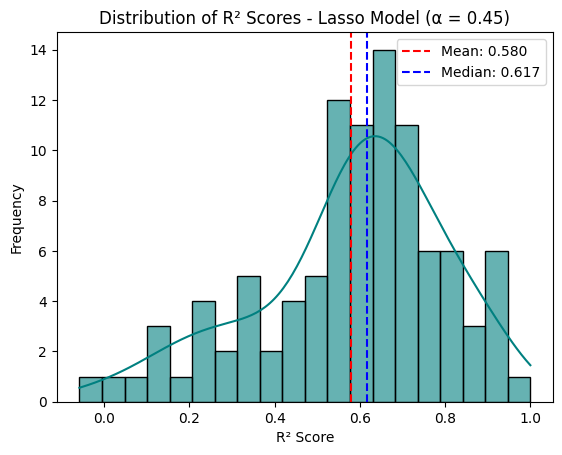

In [68]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

mean_val = np.mean(r2_list)
median_val = np.median(r2_list)

sns.histplot(r2_list, bins=20, kde=True, color='teal', alpha=0.6)

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
plt.axvline(median_val, color='blue', linestyle='--', label=f'Median: {median_val:.3f}')

plt.title("Distribution of R² Scores - Lasso Model (\u03B1 = "+str(hp)+")")
plt.xlabel("R² Score")
plt.ylabel("Frequency")

plt.legend()
plt.show()

In [69]:
all_avg_coefs = np.array(all_avg_coefs)

mean_coef = np.mean(all_avg_coefs, axis=0)
mean_abs_coef = np.mean(np.abs(all_avg_coefs), axis=0)

selection_counts = np.sum(all_avg_coefs != 0, axis=0)
selection_freq = selection_counts / all_avg_coefs.shape[0]

importance_df = pd.DataFrame({
    "coef": mean_coef,                    
    "abs_coef": np.abs(mean_coef),         
    "mean_abs_coef": mean_abs_coef,       
    "selection_freq": selection_freq,
}, index=feature_names_global)

top_20 = importance_df.sort_values(
    by=["mean_abs_coef"], 
    ascending=False
).head(20)

print(top_20)

                                       coef  abs_coef  mean_abs_coef  \
true_outside_mean_lag_1            0.101388  0.101388       0.517953   
daily_cooling_hours_lag_1          0.295550  0.295550       0.321999   
month                              0.046195  0.046195       0.169737   
setpoint_time_weighted_mean_lag_1  0.003213  0.003213       0.149787   
true_humidity_mean_lag_1           0.016122  0.016122       0.137442   
daily_runtime_hours_lag_1          0.121816  0.121816       0.123623   
daily_heating_hours_lag_1          0.109662  0.109662       0.121018   
outdoor_temp_trend_gradient        0.022559  0.022559       0.110259   

                                   selection_freq  
true_outside_mean_lag_1                  0.572628  
daily_cooling_hours_lag_1                0.343353  
month                                    0.296585  
setpoint_time_weighted_mean_lag_1        0.270488  
true_humidity_mean_lag_1                 0.284269  
daily_runtime_hours_lag_1              

# Lasso Hyperparameter Testing

In [30]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category = ConvergenceWarning)

WINDOW_SIZE  = 28
LAG_DAYS = 1

for a in [0.4, 0.45, 0.5, 0.6]:
    print("Testing for lasso with alpha =", a) 
    
    mse_list = []
    rmse_list = []
    mae_list = []
    medae_list = []
    maxae_list = []
    mape_list = []
    smape_list = []
    r2_list = []
    evs_list = []
    data_count_list = []
    dropped_rows_list = []
    flagged_list = []
    pooled_pairs = []
    
    for i in range (1, 101):
        file_path = "C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_" + str(i) +"_daily.csv"
        df = pd.read_csv(file_path)
    
        #best solution here - light gbm learns what nan means - Linear Regression doesnt.
        df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
            ["temp_gradient_mean", "setpoint_gap_mean"]
        ].fillna(0)
        
        df = df[lag_worthy_features + same_day_features]
        df = df.dropna()
        
        #filter so that we have the largest group of continuous days not missing values
        df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
        gaps = df[df['day_gap'] != 1]
        groups = (df['day_gap'] > 1).cumsum()
        try:
            largest_group = groups.value_counts().idxmax()
            df = df[groups == largest_group]
        except:
            mse_list.append(0)
            rmse_list.append(np.sqrt(0))
            mae_list.append(0)
            medae_list.append(0)
            maxae_list.append(0)
            mape_list.append(0)
            smape_list.append(0)
            #dummy r^2 value so that the list is filtered out
            r2_list.append(-10)
            evs_list.append(0)
            flagged_list.append(i*100)
            continue
            
    
        lag_cols_for_shift = [c for c in lag_worthy_features if c in df.columns]
        
        lags = []
        for j in range(1, LAG_DAYS + 1):
        
            s = df[lag_cols_for_shift].shift(j)
        
            s.columns = [f"{c}_lag_{j}" for c in s.columns]
        
            lags.append(s)
        
        df_lags = pd.concat([df] + lags, axis=1)
        
        same_day_feats = [f for f in df_lags.columns if f in same_day_features]
        
        lag_feats = [c for c in df_lags.columns if "_lag_" in c]
        
        day_only_feats = [c for c in same_day_feats if c != "daily_runtime_hours"]
        
        final_feature_set = day_only_feats + lag_feats
    
        df_lags = df_lags[final_feature_set + ["daily_runtime_hours"]]
        
        df_lags_count_initial = len(df_lags)
        df_lags_dropped = df_lags.dropna()
        df_lags_count_final = len(df_lags_dropped)
        dropped_rows_list.append(df_lags_count_initial-df_lags_count_final) 
        
        dates = df_lags_dropped["Date"]
        X = df_lags_dropped[final_feature_set].drop(columns="Date")
        y = df_lags_dropped["daily_runtime_hours"]
        
        data_count_list.append(len(X))
    
        if len(X) < (window_size * 2):
            mse_list.append(0)
            rmse_list.append(np.sqrt(0))
            mae_list.append(0)
            medae_list.append(0)
            maxae_list.append(0)
            mape_list.append(0)
            smape_list.append(0)
            #dummy r^2 value so that the list is filtered out
            r2_list.append(-10)
            evs_list.append(0)
            flagged_list.append(i)
            continue
        
        windows = []
        
        
        
        for end in range(window_size, len(y) - 1 + 1):
            start = end - window_size
        
            X_train = X[start:end]
            y_train = y[start:end]
            
            X_test = X[end:end + 1]
            y_test = y[end:end + 1]
        
            test_date = dates.iloc[end]
            
            windows.append((X_train, y_train, X_test, y_test, test_date))
    
        predictions = []
        coefs = []
        
        
        for X_train, y_train, X_test, y_test, test_date in windows:
            scaler = StandardScaler()
            
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            model = Lasso(alpha = a)
            model.fit(X_train_scaled, y_train)
            
            y_pred = model.predict(X_test_scaled)[0]
            if y_pred > 24:
                y_pred = 24
            elif y_pred < 0:
                y_pred = 0
    
            
            predictions.append({
                'y_true': y_test.iloc[0],
                'y_pred': y_pred,
                'date': test_date
            })
        
            coefs.append(model.coef_)
        
        avg_coef = np.mean(coefs, axis=0)
        pred_df = pd.DataFrame(predictions)

        pooled_pairs.append((pred_df["y_true"].to_numpy(), pred_df["y_pred"].to_numpy()))
        
        mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
        
        y_true = pred_df["y_true"].to_numpy()
        y_pred = pred_df["y_pred"].to_numpy()
    
        mae = mean_absolute_error(y_true, y_pred)
        medae = np.median(np.abs(y_true - y_pred))
        maxae = np.max(np.abs(y_true - y_pred))
    
        mape_val = mape(y_true, y_pred)
        smape_val = smape(y_true, y_pred)
    
        r2 = r2_score(y_true, y_pred)
        evs = explained_variance_score(y_true, y_pred)
    
        mse_list.append(mse)
        rmse_list.append(np.sqrt(mse))
        mae_list.append(mae)
        medae_list.append(medae)
        maxae_list.append(maxae)
        mape_list.append(mape_val)
        smape_list.append(smape_val)
        r2_list.append(r2)
        evs_list.append(evs)
    
    outlier_indices = [i for i, val in enumerate(r2_list) if val < -1]

    all_metric_lists = {
        "mse": mse_list,
        "rmse": rmse_list,
        "mae": mae_list,
        "medae": medae_list,
        "maxae": maxae_list,
        "mape": mape_list,
        "smape": smape_list,
        "r2": r2_list,
        "evs": evs_list,
        "data-count": data_count_list,
    }
    
    filtered_data = {
        name: [val for i, val in enumerate(lst) if i not in outlier_indices]
        for name, lst in all_metric_lists.items()
    }

    filtered_pairs = [
        pair for i, pair in enumerate(pooled_pairs)
        if i not in outlier_indices
    ]
    
    pooled_y_true = np.concatenate([p[0] for p in filtered_pairs])
    pooled_y_pred = np.concatenate([p[1] for p in filtered_pairs])
    
    pooled_r2 = r2_score(pooled_y_true, pooled_y_pred)
    
    mse_list = filtered_data["mse"]
    rmse_list = filtered_data["rmse"]
    mae_list = filtered_data["mae"]
    medae_list = filtered_data["medae"]
    maxae_list = filtered_data["maxae"]
    mape_list = filtered_data["mape"]
    smape_list = filtered_data["smape"]
    r2_list = filtered_data["r2"]
    evs_list = filtered_data["evs"]
    
    avg_metrics = pd.Series({
        "MSE": np.mean(mse_list),
        "RMSE": np.mean(rmse_list),
        "MAE": np.mean(mae_list),
        "MedianAE": np.mean(medae_list),
        "MaxAE": np.mean(maxae_list),
        "MAPE (%)": np.mean(mape_list),
        "sMAPE (%)": np.mean(smape_list),
        "R2": np.mean(r2_list),
        "Pooled R2": pooled_r2,
        "ExplainedVariance": np.mean(evs_list),
        "Outliers": len(outlier_indices)
    })
    
    print(avg_metrics)

Testing for lasso with alpha = 0.4
MSE                  8.407448e+00
RMSE                 2.751995e+00
MAE                  1.915666e+00
MedianAE             1.345179e+00
MaxAE                1.245781e+01
MAPE (%)             1.093701e+09
sMAPE (%)            5.242485e+01
R2                   5.790755e-01
Pooled R2            7.077715e-01
ExplainedVariance    5.806282e-01
Outliers             1.000000e+00
dtype: float64
Testing for lasso with alpha = 0.45
MSE                  8.376905e+00
RMSE                 2.749084e+00
MAE                  1.920766e+00
MedianAE             1.348709e+00
MaxAE                1.231928e+01
MAPE (%)             1.113411e+09
sMAPE (%)            5.248017e+01
R2                   5.797374e-01
Pooled R2            7.085349e-01
ExplainedVariance    5.813132e-01
Outliers             1.000000e+00
dtype: float64
Testing for lasso with alpha = 0.5
MSE                  8.362356e+00
RMSE                 2.749161e+00
MAE                  1.927735e+00
MedianAE      

# Naive Model

In [70]:
mse_list = []
rmse_list = []
mae_list = []
medae_list = []
maxae_list = []
mape_list = []
smape_list = []
r2_list = []
evs_list = []
data_count_list = []
dropped_rows_list = []
flagged_list = []
pooled_pairs = []


for i in range (1, 101):
    file_path = "C:/Users/coffm/Downloads/CIS4496/thermo-data/processed_daily/timeseries_table_" + str(i) +"_daily.csv"
    df = pd.read_csv(file_path)

    df[["temp_gradient_mean", "setpoint_gap_mean"]] = df[
        ["temp_gradient_mean", "setpoint_gap_mean"]
    ].fillna(0)
    
    df = df[lag_worthy_features + same_day_features]
    df = df.dropna()

    df['day_gap'] = pd.to_datetime(df["Date"]).diff().dt.days
    gaps = df[df['day_gap'] != 1]
    groups = (df['day_gap'] > 1).cumsum()
    try:
        largest_group = groups.value_counts().idxmax()
        df = df[groups == largest_group]
    except:
        mse_list.append(0)
        rmse_list.append(np.sqrt(0))
        mae_list.append(0)
        medae_list.append(0)
        maxae_list.append(0)
        mape_list.append(0)
        smape_list.append(0)
        #dummy r^2 value so that the list is filtered out
        r2_list.append(-10)
        evs_list.append(0)
        flagged_list.append(i*100)
        continue

    y = df["daily_runtime_hours"]

    df_model = df.copy()

    df_model["y_true"] = df_model["daily_runtime_hours"]
    df_model["y_pred"] = df_model["daily_runtime_hours"].shift(1)
    
    df_model = df_model.dropna(subset=["y_pred"])

    #cut first 28 days as they aren't part of window for linear regression rolling window
    df_model = df_model[28:]
    
    y_true = df_model["y_true"]
    y_pred = df_model["y_pred"]

    if len(df_model) == 0:
        continue

    data_count_list.append(len(df_model))
    
    mse = mean_squared_error(y_true, y_pred)
    
    y_true = y_true.to_numpy()
    y_pred = y_pred.to_numpy()

    
    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    maxae = np.max(np.abs(y_true - y_pred))

    mape_val = mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))
    mae_list.append(mae)
    medae_list.append(medae)
    maxae_list.append(maxae)
    mape_list.append(mape_val)
    smape_list.append(smape_val)
    r2_list.append(r2)
    evs_list.append(evs)
    pooled_pairs.append((df_model["y_true"].to_numpy(), df_model["y_pred"].to_numpy()))

In [71]:
outlier_indices = [i for i, val in enumerate(r2_list) if val < -1]
print(outlier_indices)

[]


In [72]:
all_metric_lists = {
    "mse": mse_list,
    "rmse": rmse_list,
    "mae": mae_list,
    "medae": medae_list,
    "maxae": maxae_list,
    "mape": mape_list,
    "smape": smape_list,
    "r2": r2_list,
    "evs": evs_list,
    "data-count": data_count_list
}

filtered_data = {
    name: [val for i, val in enumerate(lst) if i not in outlier_indices]
    for name, lst in all_metric_lists.items()
}

filtered_pairs = [
    pair for i, pair in enumerate(pooled_pairs)
    if i not in outlier_indices
]

pooled_y_true = np.concatenate([p[0] for p in filtered_pairs])
pooled_y_pred = np.concatenate([p[1] for p in filtered_pairs])

pooled_r2 = r2_score(pooled_y_true, pooled_y_pred)

mse_list = filtered_data["mse"]
rmse_list = filtered_data["rmse"]
mae_list = filtered_data["mae"]
medae_list = filtered_data["medae"]
maxae_list = filtered_data["maxae"]
mape_list = filtered_data["mape"]
smape_list = filtered_data["smape"]
r2_list = filtered_data["r2"]
evs_list = filtered_data["evs"]
data_count_list = filtered_data["data-count"]

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
    "Pooled R2": pooled_r2,
})

print(avg_metrics)

MSE                  8.716367e+00
RMSE                 2.791465e+00
MAE                  1.898978e+00
MedianAE             1.268435e+00
MaxAE                1.167727e+01
MAPE (%)             5.200456e+08
sMAPE (%)            4.788384e+01
R2                   5.517534e-01
ExplainedVariance    5.518635e-01
Pooled R2            6.959096e-01
dtype: float64


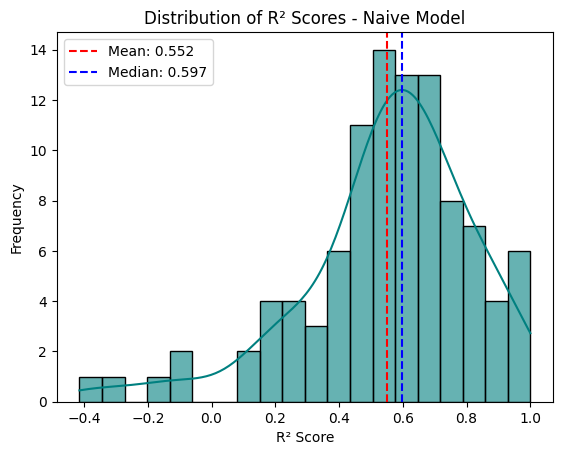

In [73]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

mean_val = np.mean(r2_list)
median_val = np.median(r2_list)

sns.histplot(r2_list, bins=20, kde=True, color='teal', alpha=0.6)

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
plt.axvline(median_val, color='blue', linestyle='--', label=f'Median: {median_val:.3f}')

plt.title("Distribution of R² Scores - Naive Model")
plt.xlabel("R² Score")
plt.ylabel("Frequency")

plt.legend()
plt.show()

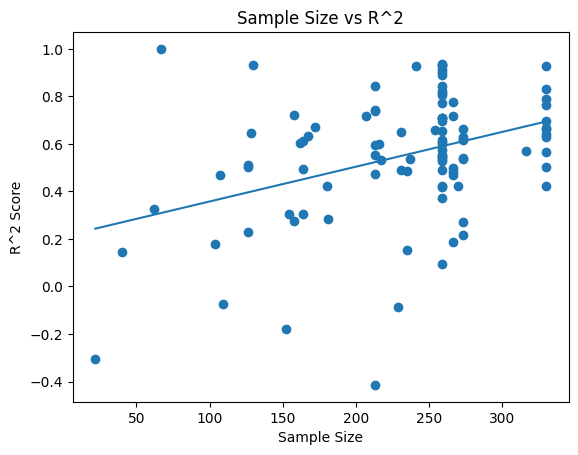

In [74]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(data_count_list, r2_list)

# fit linear trendline
z = np.polyfit(data_count_list, r2_list, 1)
p = np.poly1d(z)

# plot trendline (sorted x for clean line)
x_sorted = np.sort(data_count_list)
plt.plot(x_sorted, p(x_sorted))

plt.xlabel("Sample Size")
plt.ylabel("R^2 Score")
plt.title("Sample Size vs R^2")

plt.show()